# Greedy vs GA with walking speed.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
folder = 'outputs/runs/'

In [45]:
from utils.comparison_metrics import (
    build_results_table,
    extract_results,
    format_results_table,
    extract_cohens_d,
    calculate_poa,
    build_delta_table,
    plot_dispersion_all_cities,
    plot_metrics_by_walking_speed
)
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
from utils.environment import Environment

grid = Environment('grid-like_topology')
moderate = Environment('moderate-complexity_topology')
bottleneck = Environment('bottleneck-constrained_topology')

graphs = {
    'Grid': grid.graph, 'Moderate': moderate.graph, 'Bottleneck': bottleneck.graph
}

positions = {
    'Grid': grid.pos, 'Moderate': moderate.pos, 'Bottleneck': bottleneck.pos
}


In [5]:
baseline_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
}

# Comparisons

In [6]:
experiment_files = {
    'Grid': f'{folder}grid_city_Truewalking_Falsedelay_1compliance.pkl',
    'Moderate': f'{folder}moderate_city_Truewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Truewalking_Falsedelay_1compliance.pkl'
}

In [7]:
results = extract_results(experiment_files['Grid'])
print(f'Params: {results['ga']['params']}')   # {'walking': False, 'delay_start': False, ...}

Params: {'congestion': True, 'walking': True, 'delay_start': False, 'compliance': 1, 'fitness': 'max-median', 'alpha': 0.8}


### Step 1 - initial comparison results

In [14]:
df = build_results_table(experiment_files)
formatted = format_results_table(df)
formatted.to_clipboard()
formatted

GA                                    Greedy  \
City                    Bottleneck          Grid      Moderate    Bottleneck   
Metric                                                                         
Average time          28.21 ± 1.36  15.06 ± 0.66  15.55 ± 0.70  25.98 ± 1.32   
Avg Congestion delay  10.47 ± 0.53   3.38 ± 0.21   3.64 ± 0.25  10.68 ± 0.79   
Avg Path Efficiency    1.05 ± 0.01   1.23 ± 0.04   1.14 ± 0.02   1.00 ± 0.00   
Avg path length       12.37 ± 0.21   8.60 ± 0.33   8.58 ± 0.20  10.52 ± 0.05   
Exit utilisation       0.18 ± 0.05   0.07 ± 0.02   0.11 ± 0.04   0.18 ± 0.05   
Total time            52.40 ± 2.11  25.70 ± 1.35  26.80 ± 1.40  54.00 ± 2.68   

                                                          p                   
City                          Grid      Moderate Bottleneck    Grid Moderate  
Metric                                                                        
Average time          10.43 ± 0.47  12.39 ± 0.66     0.002*  0.002*   0.002*  
Avg Congestion delay   3.43 ± 0.23   3.85 ± 0.41      0.105   0.426   0.020*  
Avg Path Efficiency    1.00 ± 0.00   1.00 ± 0.00     0.002*  0.002*   0.002*  
Avg path length        5.00 ± 0.00   6.00 ± 0.05     0.002*  0.002*   0.002*  
Exit utilisation       0.20 ± 0.05   0.03 ± 0.02      0.945  0.002*   0.004*  
Total time            20.50 ± 0.81  25.30 ± 1.42     0.004*  0.002*   0.016*

In [15]:
extract_cohens_d(files=experiment_files)

Grid: d=5.96, p=0.002
Moderate: d=1.34, p=0.016
Bottleneck: d=-1.44, p=0.004


In [10]:
METRICS = [
    "Total time",
    "Average time",
    "Avg Congestion delay",
    "Avg path length",
    "Avg Path Efficiency",
    "Exit utilisation",
]

In [ ]:
import numpy as np
from scipy import stats

for city, path in experiment_files.items():
    results = extract_results(path)
    print(f"\n{city}")
    for metric in METRICS:
        ga_vals = np.array([e.metrics[metric] for e in results['ga']['evals']])
        greedy_vals = np.array([e.metrics[metric] for e in results['greedy']['evals']])
        diff = ga_vals - greedy_vals
        try:
            _, p = stats.wilcoxon(ga_vals, greedy_vals)
        except ValueError:
            p = 1.0
        d = diff.mean() / diff.std() if diff.std() != 0 else 0
        print(f"  {metric}: GA={ga_vals.mean():.2f}, Greedy={greedy_vals.mean():.2f}, diff={diff.mean():.2f}, p={p:.3f}, d={d:.2f}")


Grid
  Total time: GA=15.60, Greedy=11.40, diff=4.20, p=0.002, d=4.82
  Average time: GA=10.32, Greedy=7.52, diff=2.80, p=0.002, d=12.45
  Avg Congestion delay: GA=2.25, Greedy=2.52, diff=-0.27, p=0.002, d=-1.95
  Avg path length: GA=8.07, Greedy=5.00, diff=3.07, p=0.002, d=14.14
  Avg Path Efficiency: GA=1.18, Greedy=1.00, diff=0.18, p=0.002, d=6.70
  Exit utilisation: GA=0.08, Greedy=0.20, diff=-0.13, p=0.002, d=-2.26

Moderate
  Total time: GA=15.30, Greedy=15.50, diff=-0.20, p=0.727, d=-0.23
  Average time: GA=10.83, Greedy=10.02, diff=0.81, p=0.002, d=3.19
  Avg Congestion delay: GA=2.35, Greedy=4.02, diff=-1.66, p=0.002, d=-14.79
  Avg path length: GA=8.48, Greedy=6.00, diff=2.47, p=0.002, d=11.52
  Avg Path Efficiency: GA=1.11, Greedy=1.00, diff=0.11, p=0.002, d=4.85
  Exit utilisation: GA=0.10, Greedy=0.03, diff=0.07, p=0.002, d=1.82

Bottleneck
  Total time: GA=30.10, Greedy=29.00, diff=1.10, p=0.002, d=3.67
  Average time: GA=21.12, Greedy=19.50, diff=1.62, p=0.002, d=9.99
 

In [26]:
delta_df = build_delta_table(baseline_files, experiment_files, 'Baseline', 'Walking')
pivot_table = delta_df.pivot(index=['Metric', 'Algorithm'], columns='City', values='Delta')
pivot_table.to_clipboard()
pivot_table

City                            Bottleneck   Grid  Moderate
Metric               Algorithm                             
Average time         GA               7.08   4.74      4.72
                     GREEDY           6.48   2.91      2.37
Avg Congestion delay GA               1.48   1.13      1.28
                     GREEDY           1.70   0.91     -0.16
Avg Path Efficiency  GA              -0.01   0.06      0.03
                     GREEDY           0.00   0.00      0.00
Avg path length      GA               0.24   0.53      0.11
                     GREEDY           0.00   0.00      0.00
Exit utilisation     GA              -0.10  -0.00      0.00
                     GREEDY           0.00   0.00      0.00
Total time           GA              22.30  10.10     11.50
                     GREEDY          25.00   9.10      9.80

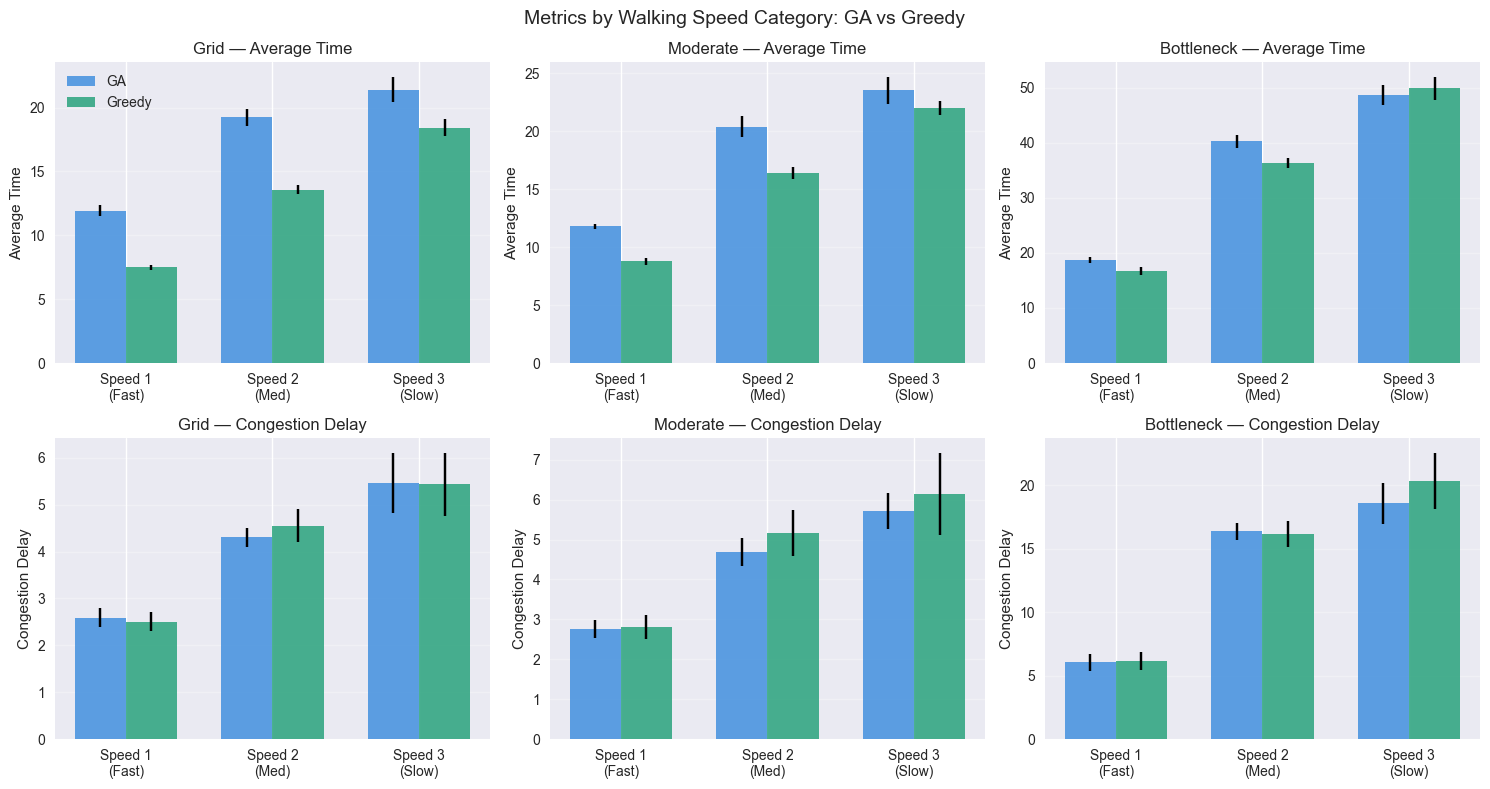

In [ ]:
plot_metrics_by_human_behaviour(experiment_files, behaviour='walking')

### Price of Anarchy

In [22]:
poa_df = calculate_poa(experiment_files)
# poa_df['Ratio (Greedy/GA)']
poa_df

,GA Mean,Greedy Mean,Ratio (Greedy/GA),Winner
Topology,,,,
Grid,25.7,20.5,0.798,Greedy
Moderate,26.8,25.3,0.944,Greedy
Bottleneck,52.4,54.0,1.031,GA


### Dispersion

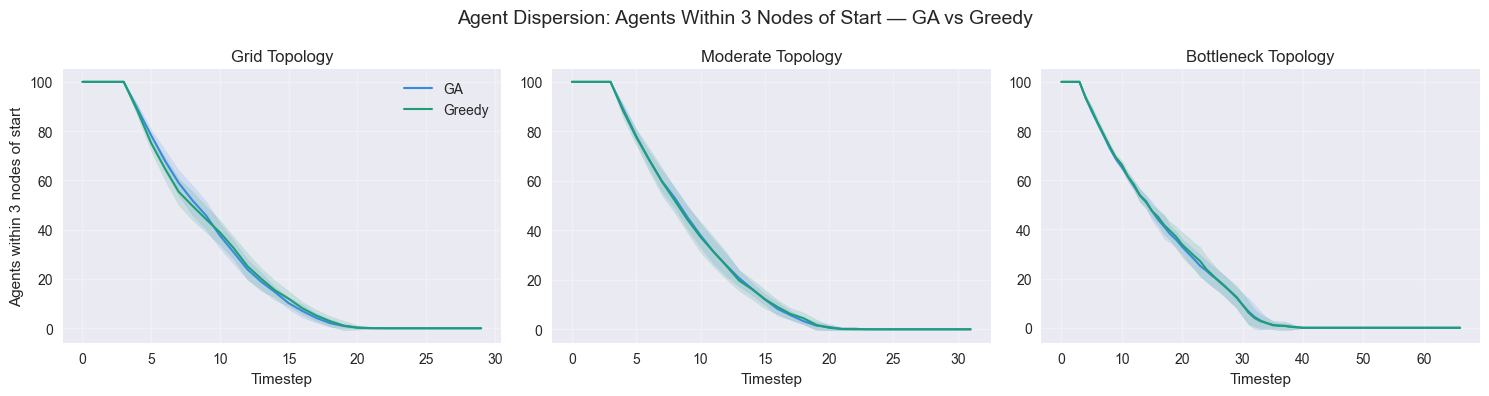

In [47]:
plot_dispersion_all_cities(experiment_files, n=3)